In [1]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
#Investigate top-paying roles and skills in the data science industry.
df_roles = df['job_title_short'].value_counts().to_frame(name = 'job_counts')
df_roles



,job_counts
job_title_short,
Data Analyst,196075
Data Engineer,186241
Data Scientist,172286
Business Analyst,49063
Software Engineer,44929
Senior Data Engineer,44563
Senior Data Scientist,36957
Senior Data Analyst,29216
Machine Learning Engineer,14080


Text(0.5, 0, 'Number Of Jobs')

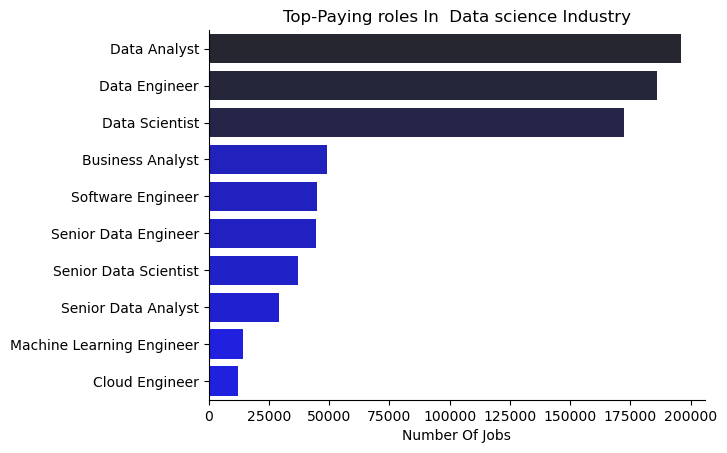

In [3]:
# sns.set_theme(style = 'ticks')
sns.barplot(data = df_roles , x = 'job_counts' , y = 'job_title_short' , hue = 'job_counts' , palette = 'dark:b_r' , legend = False)
sns.despine()
plt.title('Top-Paying roles In  Data science Industry')
plt.ylabel('')
plt.xlabel('Number Of Jobs')

In [4]:
# Analysing the number of datascience fields jobs created all over the world
df_Jobs = df['job_country'].value_counts().head(15).to_frame(name = 'job_count')
df_Jobs

,job_count
job_country,
United States,206292
India,51088
United Kingdom,40375
France,39922
Germany,27694
Spain,25100
Singapore,23696
Sudan,21781
Netherlands,20631


Text(0.5, 0, 'Number Of Jobs')

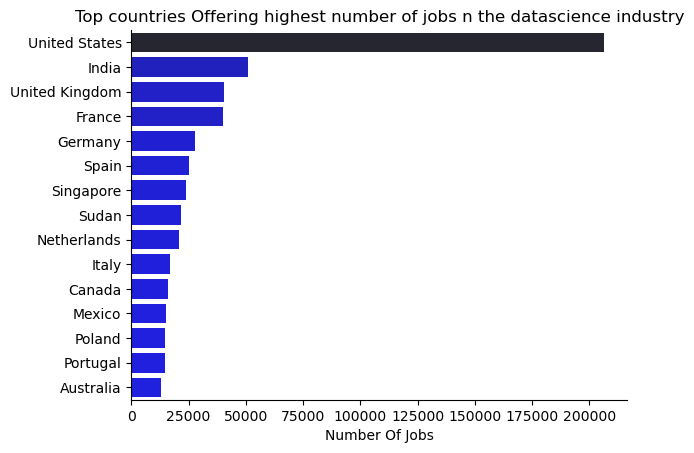

In [5]:
sns.barplot(data =  df_Jobs , x = 'job_count' , y = 'job_country' , hue = 'job_count' , palette = 'dark:b_r' , legend = False)
sns.despine()
plt.title('Top countries Offering highest number of jobs n the datascience industry')
plt.ylabel('')
plt.xlabel('Number Of Jobs')

In [6]:
# Analysing for the indian companies
df_India = df[df['job_country'] == 'India']
df_India = df_India['company_name'].value_counts().head(15).to_frame(name = 'job_count')
df_India

,job_count
company_name,
Tata Consultancy Services,432
Confidential,410
IBM,358
Visa,300
PepsiCo,262
Virtusa,256
LTIMindtree,256
Wells Fargo,252
S&P Global,241


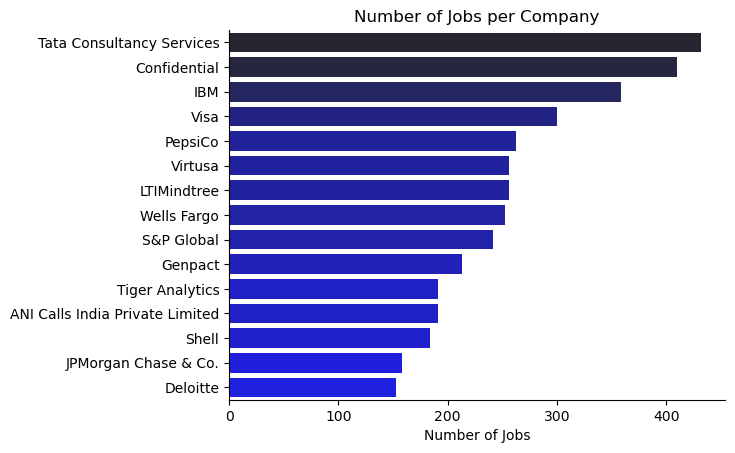

In [7]:
sns.barplot(data=df_India, x='job_count', y='company_name', hue='job_count', palette='dark:b_r', legend=False)

sns.despine()
plt.title('Number of Jobs per Company')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

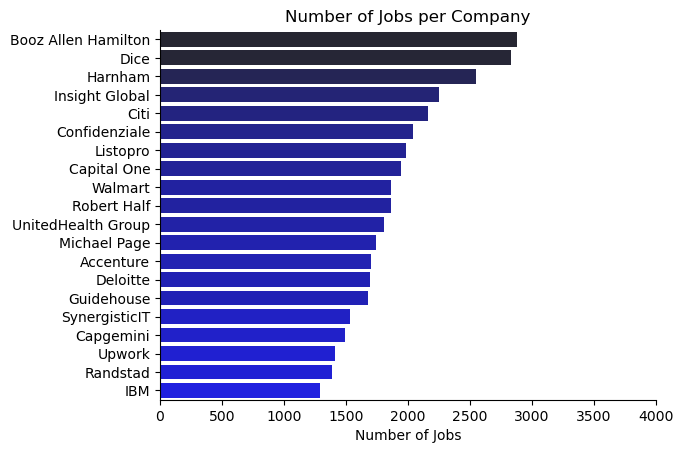

In [8]:
# Analysing the data science jobs by different companies
df_plot = df['company_name'].value_counts().to_frame()[1:].head(20)


sns.barplot(data=df_plot, x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)
plt.xlim(0,4000)
sns.despine()
plt.title('Number of Jobs per Company')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

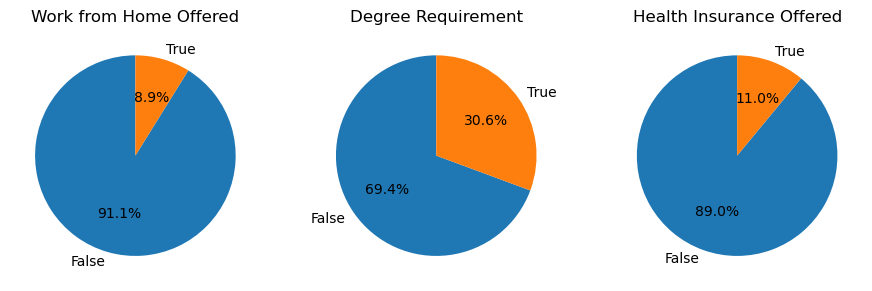

In [9]:
# analysing different parameters for the data science jobs
dict_column = {
    'job_work_from_home': 'Work from Home Offered',
    'job_no_degree_mention': 'Degree Requirement',
    'job_health_insurance': 'Health Insurance Offered'
}

fig, ax = plt.subplots(1, 3, figsize=(11, 3.5))

for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df[column].value_counts(), labels=['False', 'True'], autopct='%1.1f%%', startangle=90)
    ax[i].set_title(title)

plt.show()